In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

df = pd.read_csv('simple_logistic_regression_dataset.csv')
df.head()

,Age,Gender,City,Monthly_Income,Purchased
0,NaN,Male,NaN,"25,000",1
1,52.0,Male,Mumbai,"25,000",0
2,31.0,Male,Delhi,NaN,1
3,33.0,Male,Pune,"85,000",1
4,54.0,Male,Delhi,"25,000",1


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             94 non-null     float64
 1   Gender          93 non-null     object 
 2   City            94 non-null     object 
 3   Monthly_Income  92 non-null     object 
 4   Purchased       100 non-null    int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 4.0+ KB


Age               6
Gender            7
City              6
Monthly_Income    8
Purchased         0
dtype: int64

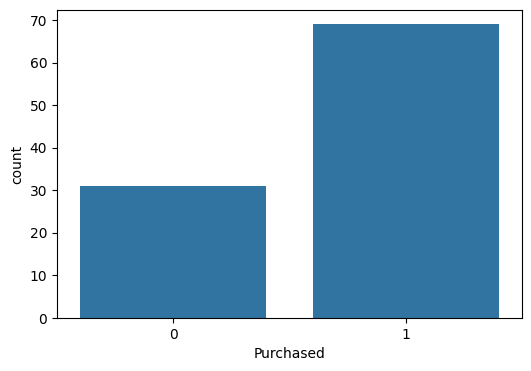

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Purchased', data=df)
plt.show()

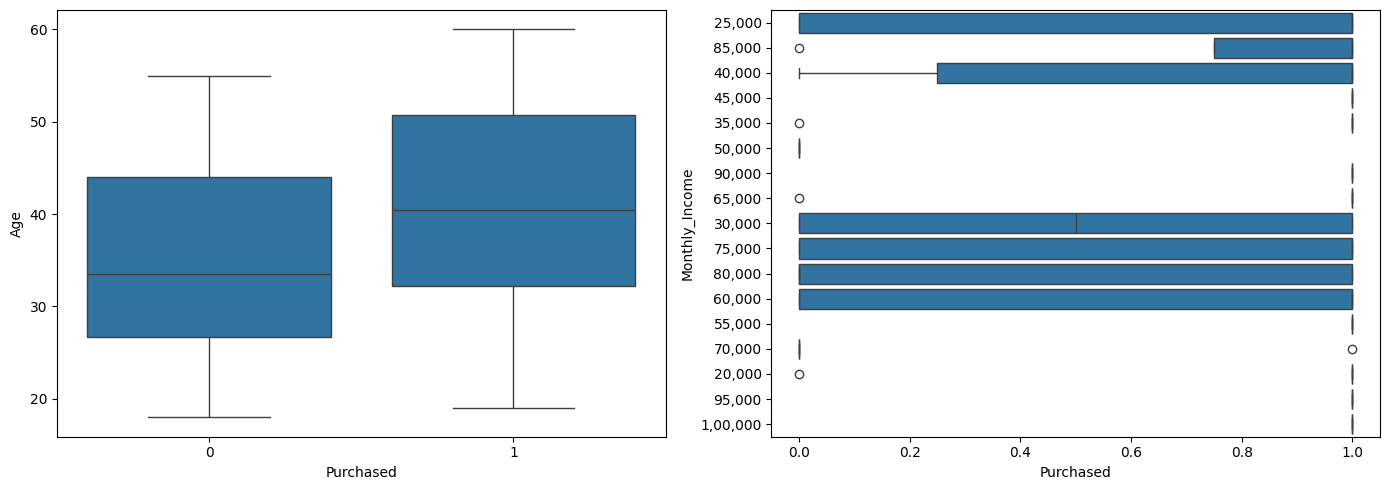

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y='Age', x='Purchased', data=df, ax=axes[0])
sns.boxplot(y='Monthly_Income', x='Purchased', data=df, ax=axes[1])
plt.tight_layout()
plt.show()

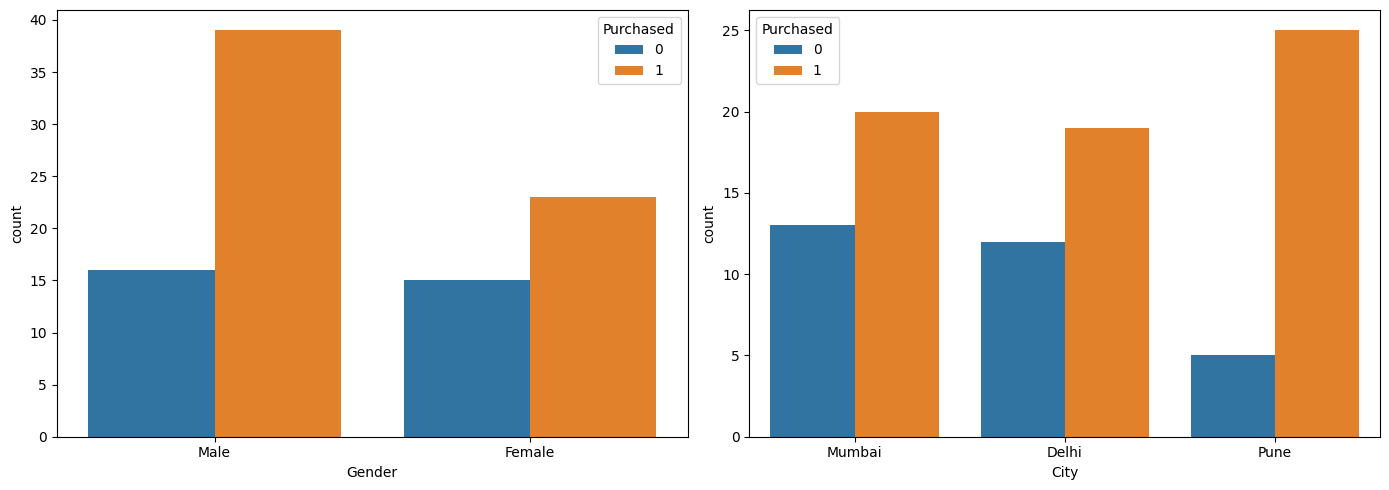

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='Gender', hue='Purchased', data=df, ax=axes[0])
sns.countplot(x='City', hue='Purchased', data=df, ax=axes[1])
plt.tight_layout()
plt.show()

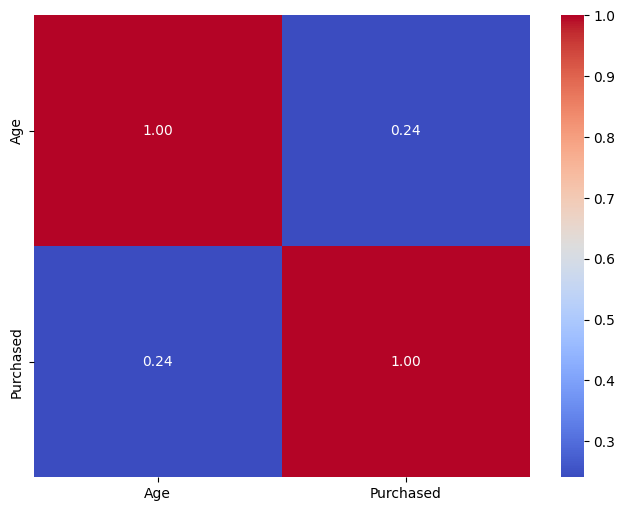

In [8]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [10]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Monthly_Income'] = pd.to_numeric(df['Monthly_Income'], errors='coerce')

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Monthly_Income'] = df['Monthly_Income'].fillna(df['Monthly_Income'].median())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])

C:\Users\ADITI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [11]:
df_encoded = pd.get_dummies(df, columns=['Gender', 'City'], drop_first=True)

In [12]:
X = df_encoded.drop(columns=['Purchased'])
y = df_encoded['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)